# UT13.2 — Modelo Preentrenado: Análisis de Noticias sobre IA en España y la UE

**Por Borja Ramos Oliva**

[Enlace a video]()

**Asignatura:** Sistemas de Aprendizaje Automático — 3.ª Evaluación  
**Trabajo:** UT13.2 VOLUNTARIO — Modelo Preentrenado  

**Descripción:** Análisis de 50 noticias reales sobre inteligencia artificial en España y Europa, combinando un modelo preentrenado de clasificación zero-shot (`joeddav/xlm-roberta-large-xnli`), NLP clásico (spaCy, TF-IDF), lógica difusa y un sistema experto basado en reglas.

---

In [1]:
# Instalación de dependencias
!pip install -q transformers torch spacy scikit-learn scikit-fuzzy pandas matplotlib nltk wordcloud
!python -m spacy download es_core_news_md -q
print('✓ Dependencias instaladas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 11.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✓ Dependencias instaladas


In [2]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from wordcloud import WordCloud
import skfuzzy as fuzz
from transformers import pipeline

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

plt.rcParams['figure.figsize'] = (12, 5)
print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


---
## 1. Descarga del Modelo Preentrenado

### ¿Qué es Hugging Face?

**Hugging Face** es la plataforma de referencia en el ecosistema de inteligencia artificial para compartir modelos, datasets y aplicaciones de machine learning. Su biblioteca `transformers` permite cargar y usar modelos de última generación con pocas líneas de código, sin necesidad de entrenar desde cero.

### ¿Por qué usar un modelo preentrenado?

Los modelos preentrenados han sido entrenados sobre miles de millones de documentos, capturando representaciones semánticas ricas del lenguaje (**transfer learning**). Esto permite:
- Obtener resultados de alta calidad sin datos etiquetados propios
- Reducir drásticamente el tiempo y coste computacional
- Aplicar el conocimiento lingüístico directamente mediante *zero-shot classification*

### Modelo elegido: `joeddav/xlm-roberta-large-xnli`

[Enlace a su página de HuggingFace aquí](https://huggingface.co/joeddav/xlm-roberta-large-xnli)

| Característica | Detalle |
|---|---|
| Arquitectura | XLM-RoBERTa Large (transformer multilingüe) |
| Preentrenamiento | Masked Language Modeling + XNLI (Natural Language Inference) |
| Idiomas | 100 idiomas, incluido español |
| Tarea aplicada | Zero-shot classification |
| Parámetros | ~560 millones |

**Justificación:** Está ajustado para NLI, lo que lo hace ideal para zero-shot. Es multilingüe y maneja el español con alta precisión sin corpus etiquetado.

In [3]:
# Configuración del modelo (se cargará en la sección 5.3)
MODELO_ID = 'joeddav/xlm-roberta-large-xnli'
TAREA = 'zero-shot-classification'

CANDIDATE_LABELS = [
    'inteligencia artificial',
    'regulación',
    'economía digital',
    'empleo',
    'educación',
    'sanidad',
    'ciberseguridad',
    'administración pública'
]

print(f'Modelo: {MODELO_ID}')
print(f'Tarea:  {TAREA}')
print(f'Etiquetas ({len(CANDIDATE_LABELS)}):')
for i, lbl in enumerate(CANDIDATE_LABELS, 1):
    print(f'  {i}. {lbl}')

Modelo: joeddav/xlm-roberta-large-xnli
Tarea:  zero-shot-classification
Etiquetas (8):
  1. inteligencia artificial
  2. regulación
  3. economía digital
  4. empleo
  5. educación
  6. sanidad
  7. ciberseguridad
  8. administración pública


---
## 2. Dataset Utilizado

### Origen
Dataset recopilado manualmente a partir de fuentes especializadas: La Razón, Europa Press, Comisión Europea, Ministerio para la Transformación Digital, Deloitte, CyberMadrid, INCIBE, entre otros.

### Estructura

| Campo | Descripción |
|---|---|
| `id` | Identificador único |
| `fecha` | Fecha de publicación (2022–2026) |
| `pais_region` | País o región de referencia |
| `fuente` | Medio o institución |
| `titulo` | Titular de la noticia |
| `resumen` | Resumen del contenido |
| `categoria_manual` | Etiqueta asignada por un humano (multietiqueta) |
| `terminos_clave` | Palabras clave identificadas |

**Texto de análisis:** `df['texto'] = df['titulo'] + '. ' + df['resumen']`  
**`terminos_clave`** no se analiza directamente; se usa `categoria_manual` como referencia.

### Limitaciones
- Dataset pequeño (50 noticias) → solo válido para análisis, no para entrenamiento
- Las categorías manuales son compuestas → comparación aproximada con el modelo
- Rango temporal amplio (2022–2026) → posibles sesgos temporales

In [4]:
# Carga del dataset (local o Google Colab)
DATA_FILE = 'noticias.json'

if os.path.exists(DATA_FILE):
    df = pd.read_json(DATA_FILE)
    print(f'✓ Cargado desde disco: {DATA_FILE}')
else:
    try:
        from google.colab import files
        import io
        print('Sube el archivo noticias.json:')
        uploaded = files.upload()
        df = pd.read_json(io.BytesIO(list(uploaded.values())[0]))
        print('✓ Archivo cargado')
    except ImportError:
        raise FileNotFoundError(f"No se encontró '{DATA_FILE}'.")

df['texto'] = df['titulo'] + '. ' + df['resumen']
df['fecha'] = pd.to_datetime(df['fecha'])

print(f'Noticias totales : {len(df)}')
print(f'Rango de fechas  : {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print(f'Columnas         : {list(df.columns)}')
df.head(3)

Sube el archivo noticias.json:


Saving noticias.json to noticias.json
✓ Archivo cargado
Noticias totales : 50
Rango de fechas  : 2022-07-01 → 2026-05-21
Columnas         : ['id', 'fecha', 'pais_region', 'fuente', 'url', 'titulo', 'resumen', 'categoria_manual', 'terminos_clave', 'texto']


,id,fecha,pais_region,fuente,url,titulo,resumen,categoria_manual,terminos_clave,texto
0,1,2026-03-02,España / Unión Europea,La Razón,https://www.larazon.es/economia/espana-moviliz...,España moviliza 100 millones para proyectos de...,El Gobierno español ha anunciado una partida d...,economía digital / política industrial / IA,"[IPCEI IA, soberanía digital, subvenciones, ec...",España moviliza 100 millones para proyectos de...
1,2,2026-05-13,España,EciJA / análisis jurídico,https://www.ecija.com/actualidad-insights/espa...,España avanza en el Anteproyecto de Ley de IA ...,El Anteproyecto de Ley español sobre buen uso ...,regulación tecnológica / IA,"[Anteproyecto Ley IA, CES, gobernanza, sancion...",España avanza en el Anteproyecto de Ley de IA ...
2,3,2026-01-19,Unión Europea,DOUE / BOE,https://www.boe.es/buscar/doc.php?id=DOUE-L-20...,La UE refuerza la Empresa Común de Informática...,El Reglamento (UE) 2026/150 modifica el marco ...,infraestructura digital / supercomputación / IA,"[EuroHPC, supercomputación, alta computación, ...",La UE refuerza la Empresa Común de Informática...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                50 non-null     int64         
 1   fecha             50 non-null     datetime64[ns]
 2   pais_region       50 non-null     object        
 3   fuente            50 non-null     object        
 4   url               50 non-null     object        
 5   titulo            50 non-null     object        
 6   resumen           50 non-null     object        
 7   categoria_manual  50 non-null     object        
 8   terminos_clave    50 non-null     object        
 9   texto             50 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 4.0+ KB


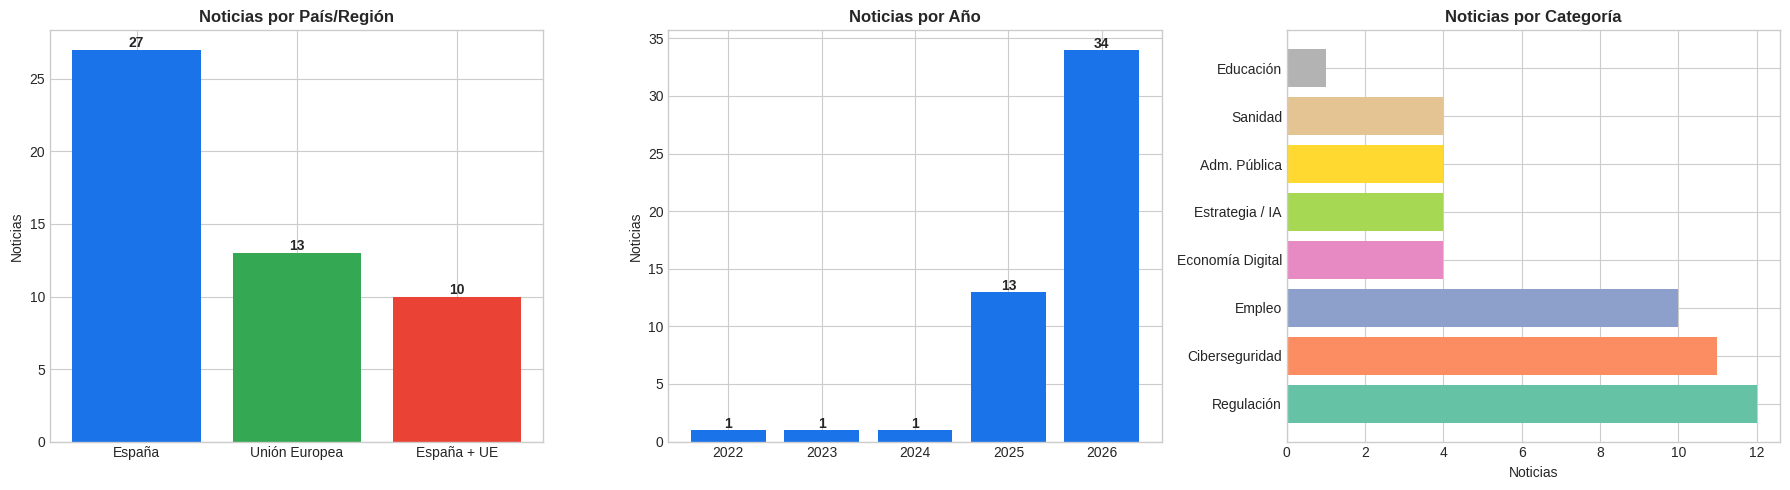

In [6]:
# Función auxiliar: simplificar país/región
def extraer_pais(p):
    if 'España' in p and ('Unión' in p or 'UE' in p):
        return 'España + UE'
    elif 'España' in p:
        return 'España'
    elif 'Unión' in p or 'UE' in p:
        return 'Unión Europea'
    return 'Internacional'

# Función auxiliar: simplificar categoría manual
def simplificar_categoria(cat):
    c = cat.lower()
    if 'ciberseguridad' in c:
        return 'Ciberseguridad'
    elif 'regulaci' in c or 'cumplimiento' in c:
        return 'Regulación'
    elif 'empleo' in c or 'automati' in c or 'laboral' in c:
        return 'Empleo'
    elif 'sanidad' in c or 'salud' in c:
        return 'Sanidad'
    elif 'educaci' in c or 'formaci' in c:
        return 'Educación'
    elif 'administraci' in c:
        return 'Adm. Pública'
    elif 'econom' in c or 'pymes' in c or 'industrial' in c:
        return 'Economía Digital'
    return 'Estrategia / IA'

df['pais_simple'] = df['pais_region'].apply(extraer_pais)
df['categoria_simple'] = df['categoria_manual'].apply(simplificar_categoria)
df['anio'] = df['fecha'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Noticias por país
cp = df['pais_simple'].value_counts()
axes[0].bar(cp.index, cp.values, color=['#1a73e8','#34a853','#ea4335','#fbbc04'])
axes[0].set_title('Noticias por País/Región', fontweight='bold')
axes[0].set_ylabel('Noticias')
for i, v in enumerate(cp.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# — Noticias por año
ca = df['anio'].value_counts().sort_index()
axes[1].bar(ca.index.astype(str), ca.values, color='#1a73e8')
axes[1].set_title('Noticias por Año', fontweight='bold')
axes[1].set_ylabel('Noticias')
for i, v in enumerate(ca.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# — Noticias por categoría
cc = df['categoria_simple'].value_counts()
colores = plt.cm.Set2(np.linspace(0, 1, len(cc)))
axes[2].barh(cc.index, cc.values, color=colores)
axes[2].set_title('Noticias por Categoría', fontweight='bold')
axes[2].set_xlabel('Noticias')

plt.tight_layout()
plt.savefig('distribucion_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Problema que se Intenta Resolver

El periodismo sobre tecnología genera un volumen creciente de contenido difícil de categorizar manualmente. Este análisis combina **NLP clásico** y **modelos preentrenados** para:

1. **Detectar automáticamente** qué noticias tienen mayor relevancia en materia de IA
2. **Clasificar semánticamente** el contenido sin datos etiquetados (*zero-shot*)
3. **Cuantificar la relevancia** de la IA mediante un índice compuesto
4. **Aplicar razonamiento experto** con lógica difusa para manejar la incertidumbre

La combinación de ambos enfoques supera las limitaciones individuales: el NLP clásico aporta interpretabilidad; el modelo preentrenado, comprensión semántica profunda; la lógica difusa maneja la gradación de relevancia; el sistema experto incorpora conocimiento del dominio.

---
## 4. Explicación del Modelo

### 4.1 Cómo funciona

**XLM-RoBERTa** es un transformer multilingüe basado en BERT, preentrenado con *Masked Language Modeling* sobre 2,5 TB de texto en 100 idiomas.

- **Tokenización:** Convierte el texto en *tokens* (subpalabras) usando SentencePiece (~250k vocabulario). Cada token recibe un ID numérico.
- **Embeddings:** Cada token se representa como un vector de 1024 dimensiones (variante *large*) que captura su significado contextual.
- **Zero-shot classification:** Mediante *Natural Language Inference (NLI)*, el modelo decide si la hipótesis «Esta noticia trata sobre [etiqueta]» es *verdadera*, *falsa* o *neutra* respecto al texto. El score de verdad se convierte en la probabilidad de clasificación.

### 4.2 Cómo se parametriza

```python
clasificador = pipeline(
    'zero-shot-classification',
    model='joeddav/xlm-roberta-large-xnli'
)
resultado = clasificador(
    texto,
    candidate_labels=CANDIDATE_LABELS,  # 8 categorías
    multi_label=False                   # clasificación exclusiva
)
```

### 4.3 Cambios en la arquitectura

El modelo se usa **sin modificaciones**. No se realiza fine-tuning ni entrenamiento adicional. Se aprovecha el conocimiento del preentrenamiento directamente mediante zero-shot.

---
## 5. Ejemplo de Funcionamiento

Pipeline completo:

```
Texto bruto
    → [5.1] Preprocesamiento spaCy  → texto_limpio
    → [5.2] NLP clásico             → TF-IDF, bigramas, wordcloud
    → [5.3] Modelo zero-shot        → categoria_modelo, score_modelo
    → [5.4] Lógica difusa           → fuzzy_relevancia, nivel_relevancia
    → [5.5] Sistema experto         → categoria_experta
    → [5.6] Índice IA compuesto     → ia_index, TOP 10
```

### 5.1 Preprocesamiento con spaCy

Se aplica el modelo `es_core_news_md` de spaCy para:
- **Tokenización:** división del texto en unidades lingüísticas
- **Lematización:** reducción de cada token a su forma canónica
- **Limpieza:** eliminación de stopwords, puntuación, espacios y tokens cortos

El resultado se guarda en `df['texto_limpio']`.

In [7]:
nlp = spacy.load('es_core_news_md')
STOPWORDS_ES = set(stopwords.words('spanish'))

def preprocesar_texto(texto):
    doc = nlp(texto.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
        and len(token.text) > 2
        and token.lemma_ not in STOPWORDS_ES
    ]
    return ' '.join(tokens)

df['texto_limpio'] = df['texto'].apply(preprocesar_texto)

print('✓ Preprocesamiento completado')
print(f'\nEjemplo — Texto original (ID 4):')
print(df['texto'].iloc[3][:250])
print(f'\nEjemplo — Texto lematizado:')
print(df['texto_limpio'].iloc[3][:250])

✓ Preprocesamiento completado

Ejemplo — Texto original (ID 4):
La Ley de IA de la UE entra en fase de aplicación progresiva. La Ley de Inteligencia Artificial de la UE, primer marco jurídico integral sobre esta tecnología, ha comenzado su despliegue gradual con obligaciones diferenciadas según el nivel de riesgo

Ejemplo — Texto lematizado:
ley entrar fase aplicación progresivo ley inteligencia artificial marco jurídico integral tecnología comenzar despliegue gradual obligación diferenciado nivel riesgo sistema reforzar protección derecho fundamental exigir requisito estricto transparen


In [8]:
# Análisis de tokens para una noticia de ejemplo
doc_ejemplo = nlp(df['texto'].iloc[3])

print(f'{"Token":<22} {"Lema":<22} {"POS":<12} {"Es stop"}')
print('-' * 65)
for token in list(doc_ejemplo)[:18]:
    print(f'{token.text:<22} {token.lemma_:<22} {token.pos_:<12} {token.is_stop}')

Token                  Lema                   POS          Es stop
-----------------------------------------------------------------
La                     el                     DET          True
Ley                    Ley                    PROPN        False
de                     de                     ADP          True
IA                     IA                     PROPN        False
de                     de                     ADP          True
la                     el                     DET          True
UE                     UE                     PROPN        False
entra                  entrar                 VERB         False
en                     en                     ADP          True
fase                   fase                   NOUN         False
de                     de                     ADP          True
aplicación             aplicación             NOUN         False
progresiva             progresivo             ADJ          False
.                      .    

### 5.2 NLP Clásico

Se aplican tres técnicas clásicas de NLP:
- **TF-IDF** (*Term Frequency–Inverse Document Frequency*): pondera términos relevantes en el corpus
- **N-gramas (bigramas)**: identifica pares de términos que aparecen juntos con frecuencia
- **Frecuencia absoluta** de términos clave específicos del dominio IA

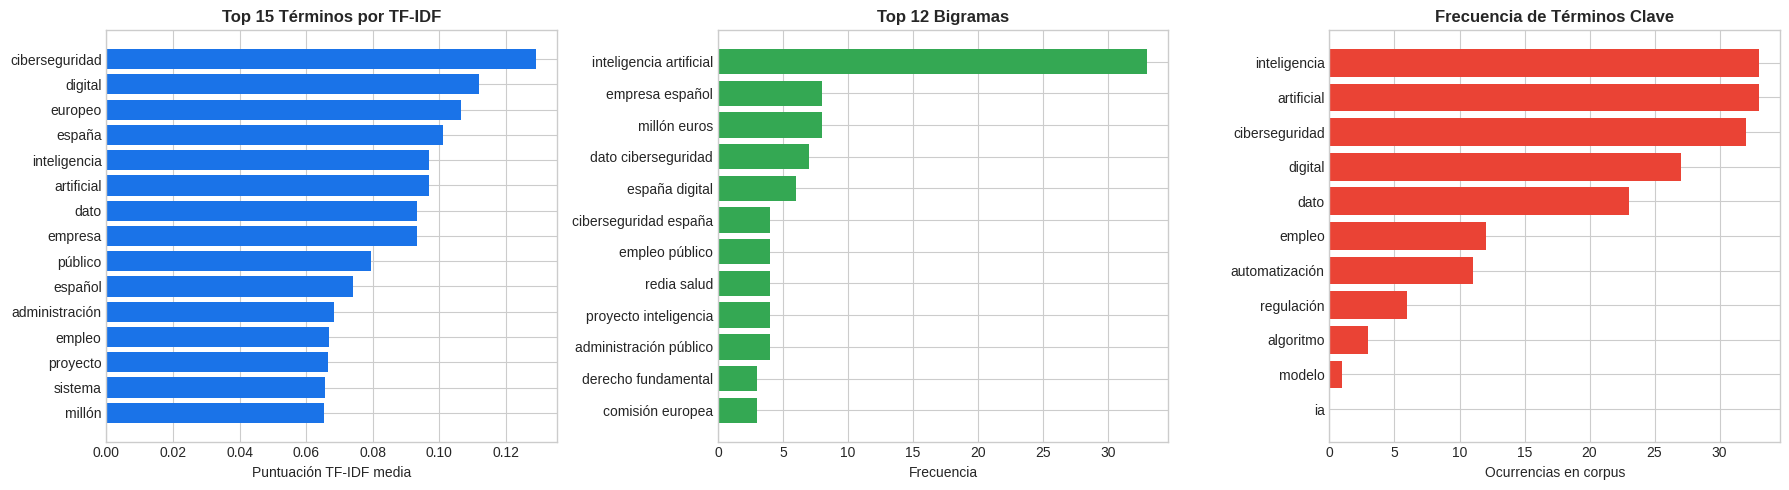

In [9]:
# ── TF-IDF ──────────────────────────────────────────────────────────────────
vec_tfidf = TfidfVectorizer(max_features=50, ngram_range=(1, 1))
X_tfidf = vec_tfidf.fit_transform(df['texto_limpio'])
importancias = X_tfidf.mean(axis=0).A1
vocab_tfidf = vec_tfidf.get_feature_names_out()
top_tfidf = pd.Series(importancias, index=vocab_tfidf).sort_values(ascending=False).head(15)

# ── Bigramas ─────────────────────────────────────────────────────────────────
vec_bigram = CountVectorizer(ngram_range=(2, 2), max_features=30)
X_bigram = vec_bigram.fit_transform(df['texto_limpio'])
freq_bigram = X_bigram.sum(axis=0).A1
vocab_bigram = vec_bigram.get_feature_names_out()
top_bigrams = pd.Series(freq_bigram, index=vocab_bigram).sort_values(ascending=False).head(12)

# ── Frecuencia de términos clave ─────────────────────────────────────────────
TERMINOS_CLAVE = [
    'ia', 'inteligencia', 'artificial', 'automatización',
    'algoritmo', 'ciberseguridad', 'digital', 'dato',
    'regulación', 'empleo', 'modelo'
]
todo_texto = ' '.join(df['texto_limpio'])
freq_clave = {t: todo_texto.split().count(t) for t in TERMINOS_CLAVE}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(top_tfidf.index[::-1], top_tfidf.values[::-1], color='#1a73e8')
axes[0].set_title('Top 15 Términos por TF-IDF', fontweight='bold')
axes[0].set_xlabel('Puntuación TF-IDF media')

axes[1].barh(top_bigrams.index[::-1], top_bigrams.values[::-1], color='#34a853')
axes[1].set_title('Top 12 Bigramas', fontweight='bold')
axes[1].set_xlabel('Frecuencia')

freq_serie = pd.Series(freq_clave).sort_values()
axes[2].barh(freq_serie.index, freq_serie.values, color='#ea4335')
axes[2].set_title('Frecuencia de Términos Clave', fontweight='bold')
axes[2].set_xlabel('Ocurrencias en corpus')

plt.tight_layout()
plt.savefig('nlp_clasico.png', dpi=150, bbox_inches='tight')
plt.show()

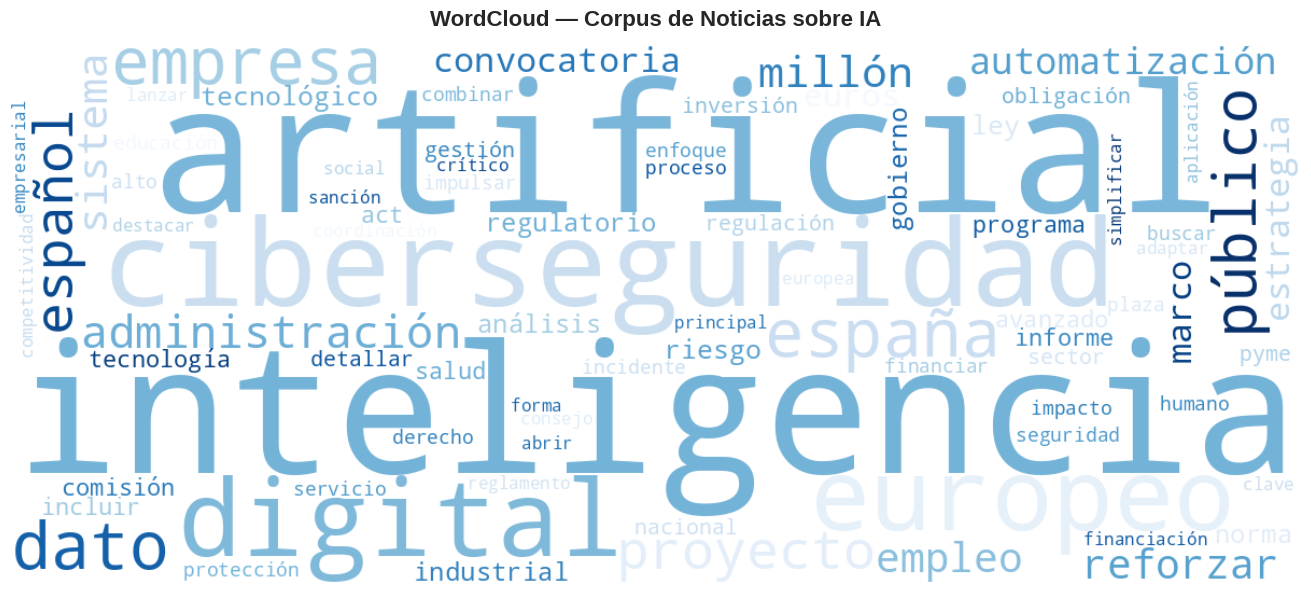

In [10]:
texto_corpus = ' '.join(df['texto_limpio'])

wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    colormap='Blues',
    max_words=80,
    collocations=False
).generate(texto_corpus)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Corpus de Noticias sobre IA', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Modelo Preentrenado — Zero-Shot Classification

Se carga el pipeline de Hugging Face con `joeddav/xlm-roberta-large-xnli` y se clasifica cada noticia en una de las 8 etiquetas candidatas. El parámetro `multi_label=False` fuerza una clasificación exclusiva.

> **Nota:** La primera ejecución descarga el modelo (~1,5 GB). Puede tardar 3–8 minutos en Colab.

In [11]:
print('Cargando modelo (puede tardar varios minutos la primera vez)...')
clasificador = pipeline(
    'zero-shot-classification',
    model=MODELO_ID,
    device=-1  # CPU; cambiar a 0 para GPU en Colab
)
print('✓ Modelo cargado')

Cargando modelo (puede tardar varios minutos la primera vez)...


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

✓ Modelo cargado


In [12]:
categorias_modelo = []
scores_modelo = []
n = len(df)

for i, texto in enumerate(df['texto']):
    resultado = clasificador(
        texto[:512],
        candidate_labels=CANDIDATE_LABELS,
        multi_label=False
    )
    categorias_modelo.append(resultado['labels'][0])
    scores_modelo.append(resultado['scores'][0])
    if (i + 1) % 10 == 0 or i == 0:
        print(f'  [{i+1}/{n}] {resultado["labels"][0]:30s} score={resultado["scores"][0]:.3f}')

df['categoria_modelo'] = categorias_modelo
df['score_modelo'] = scores_modelo
print(f'\n✓ Clasificación completada | Score medio: {df["score_modelo"].mean():.3f}')

  [1/50] inteligencia artificial        score=0.385
  [10/50] regulación                     score=0.393
  [20/50] educación                      score=0.805
  [30/50] regulación                     score=0.532
  [40/50] economía digital               score=0.314
  [50/50] ciberseguridad                 score=0.324

✓ Clasificación completada | Score medio: 0.666


In [13]:
# Resultados por noticia
print(f'{"ID":<5} {"Categoría modelo":<30} {"Score":<8} Categoría manual')
print('-' * 85)
for _, row in df.iterrows():
    print(f'{row["id"]:<5} {row["categoria_modelo"]:<30} {row["score_modelo"]:.3f}   {row["categoria_manual"][:40]}')

ID    Categoría modelo               Score    Categoría manual
-------------------------------------------------------------------------------------
1     inteligencia artificial        0.385   economía digital / política industrial /
2     inteligencia artificial        0.749   regulación tecnológica / IA
3     regulación                     0.818   infraestructura digital / supercomputaci
4     inteligencia artificial        0.536   regulación tecnológica / IA
5     regulación                     0.964   regulación tecnológica / cumplimiento
6     regulación                     0.362   regulación tecnológica / ciberseguridad
7     economía digital               0.838   economía digital / regulación tecnológic
8     regulación                     0.849   regulación tecnológica / contenidos digi
9     regulación                     0.842   regulación tecnológica / empresa
10    regulación                     0.393   regulación tecnológica / ciberseguridad 
11    ciberseguridad         

Accuracy zero-shot vs. categoría manual (aproximada): 40.0%
Aciertos: 20/50

Nota: la comparación es aproximada porque las categorías manuales
son compuestas y multietiqueta, mientras el modelo asigna una sola.


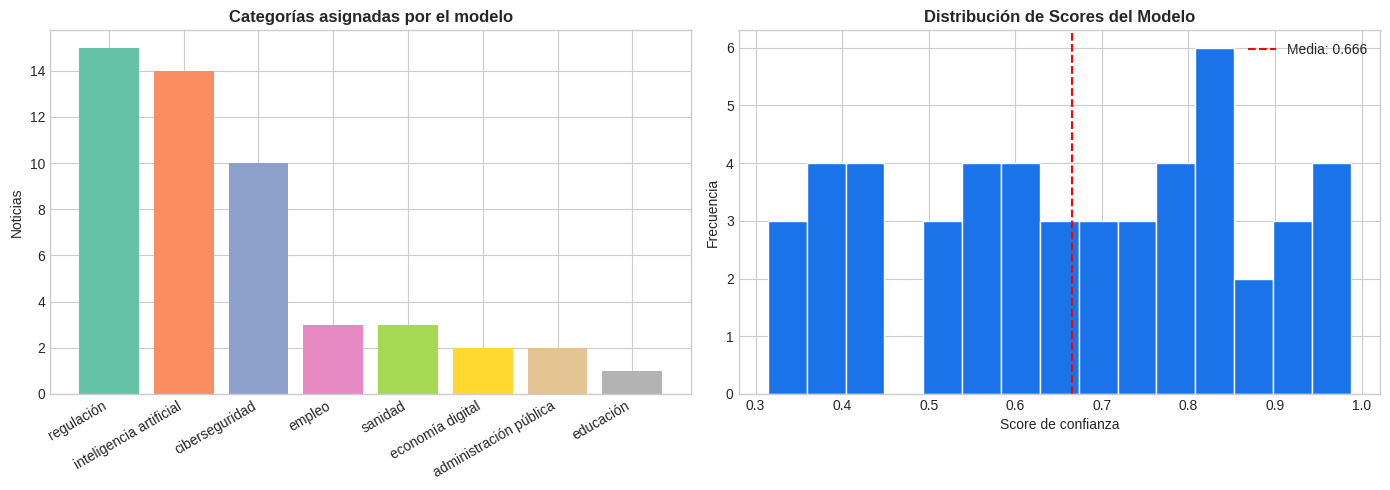

In [14]:
# Mapeo de categoría manual a etiqueta del modelo (para comparación)
LABEL_MAP = {
    'inteligencia artificial': ['estrategia', 'ia general', 'infraestructura'],
    'regulación':              ['regulaci', 'cumplimiento', 'ai act', 'normativa', 'ley'],
    'economía digital':        ['econom', 'pymes', 'industrial', 'innov', 'digital', 'financiaci'],
    'empleo':                  ['empleo', 'automati', 'laboral', 'robot', 'trabajo'],
    'educación':               ['educaci', 'formaci', 'enseñanza', 'docente', 'stem'],
    'sanidad':                 ['sanidad', 'salud', 'hospital', 'médic', 'clíni'],
    'ciberseguridad':          ['ciberseguridad', 'ciberataque', 'incibe', 'amenaza', 'nis2'],
    'administración pública':  ['administraci', 'función pública', 'inap', 'tramit', 'oep']
}

def mapear_etiqueta(cat_manual):
    c = cat_manual.lower()
    for etiqueta, patrones in LABEL_MAP.items():
        if any(p in c for p in patrones):
            return etiqueta
    return 'inteligencia artificial'

df['categoria_ref'] = df['categoria_manual'].apply(mapear_etiqueta)

aciertos = (df['categoria_modelo'] == df['categoria_ref']).sum()
accuracy = aciertos / len(df)
print(f'Accuracy zero-shot vs. categoría manual (aproximada): {accuracy:.1%}')
print(f'Aciertos: {aciertos}/{len(df)}')
print()
print('Nota: la comparación es aproximada porque las categorías manuales')
print('son compuestas y multietiqueta, mientras el modelo asigna una sola.')

# Visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm_counts = df['categoria_modelo'].value_counts()
ax1.bar(range(len(cm_counts)), cm_counts.values,
        color=plt.cm.Set2(np.linspace(0, 1, len(cm_counts))))
ax1.set_xticks(range(len(cm_counts)))
ax1.set_xticklabels(cm_counts.index, rotation=30, ha='right')
ax1.set_title('Categorías asignadas por el modelo', fontweight='bold')
ax1.set_ylabel('Noticias')

ax2.hist(df['score_modelo'], bins=15, color='#1a73e8', edgecolor='white')
ax2.axvline(df['score_modelo'].mean(), color='red', linestyle='--',
            label=f'Media: {df["score_modelo"].mean():.3f}')
ax2.set_title('Distribución de Scores del Modelo', fontweight='bold')
ax2.set_xlabel('Score de confianza')
ax2.set_ylabel('Frecuencia')
ax2.legend()

plt.tight_layout()
plt.savefig('modelo_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

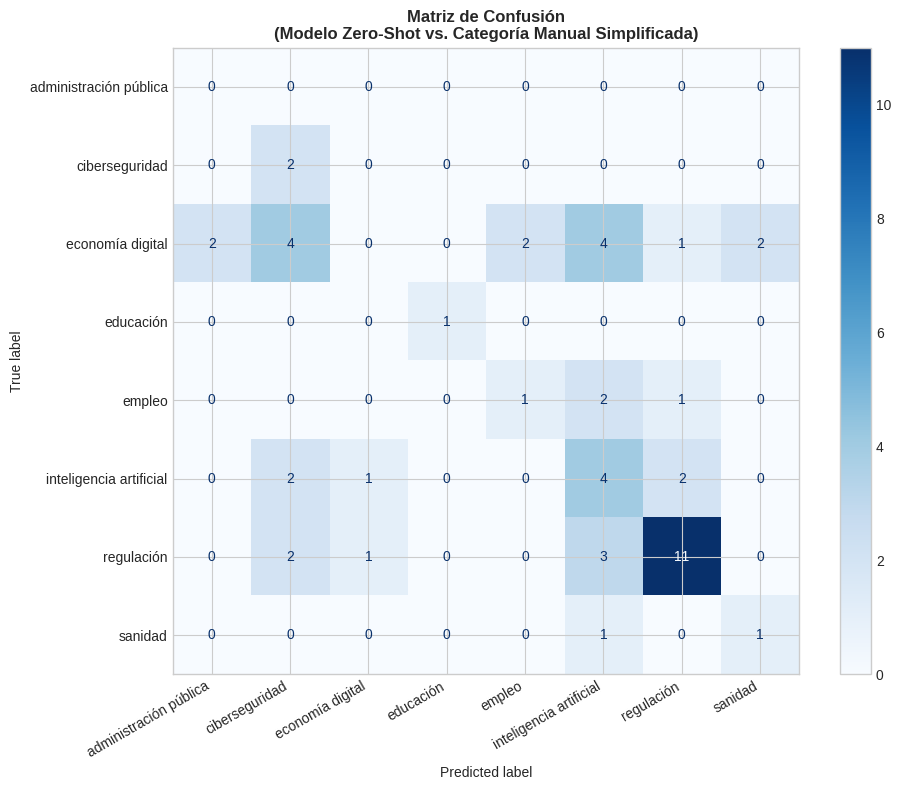

In [15]:
# Matriz de confusión (aproximada)
all_cats = sorted(set(df['categoria_ref'].unique()) | set(df['categoria_modelo'].unique()))
cm = confusion_matrix(df['categoria_ref'], df['categoria_modelo'], labels=all_cats)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_cats)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión\n(Modelo Zero-Shot vs. Categoría Manual Simplificada)',
             fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Sistema de Lógica Difusa

Se construye un sistema difuso tipo **Mamdani** para calcular el índice `relevancia_ia` de cada noticia.

**Entradas (normalizadas a [0,1]):**
- `freq_ia`: frecuencia de términos relacionados con IA en el texto
- `score_modelo`: score de confianza del modelo zero-shot
- `densidad`: proporción de términos tecnológicos en el texto lematizado

**Salida:**
- `relevancia_ia` con niveles lingüísticos: **baja**, **media**, **alta**

**Funciones de pertenencia:** triangulares (trimf) sobre el universo [0, 1]  
**Defuzzificación:** método del centroide

In [16]:
# Calcular entradas del sistema difuso
TERMINOS_IA = [
    'ia', 'inteligencia artificial', 'algoritmo', 'machine learning',
    'deep learning', 'automatización', 'neural', 'robot', 'chatbot',
    'llm', 'ia generativa', 'aprendizaje automático'
]

TERMINOS_DENSIDAD = {
    'inteligencia', 'artificial', 'algoritmo', 'automatización',
    'digital', 'dato', 'modelo', 'robot', 'tecnología', 'neural',
    'aprendizaje', 'máquina', 'sistema', 'análisis', 'predicción',
    'red', 'entrenamiento', 'clasificación', 'transformer'
}

def freq_ia_norm(texto):
    t = texto.lower()
    palabras = max(len(t.split()), 1)
    conteo = sum(t.count(term) for term in TERMINOS_IA)
    return min(conteo / palabras * 20, 1.0)

def densidad_norm(texto_limpio):
    tokens = texto_limpio.split()
    if not tokens:
        return 0.0
    hits = sum(1 for t in tokens if t in TERMINOS_DENSIDAD)
    return min(hits / len(tokens) * 3, 1.0)

df['freq_ia_norm'] = df['texto'].apply(freq_ia_norm)
df['densidad_norm'] = df['texto_limpio'].apply(densidad_norm)

print(f'Frecuencia IA media  : {df["freq_ia_norm"].mean():.3f}')
print(f'Densidad términos    : {df["densidad_norm"].mean():.3f}')
print(f'Score modelo medio   : {df["score_modelo"].mean():.3f}')

Frecuencia IA media  : 0.904
Densidad términos    : 0.312
Score modelo medio   : 0.666


In [17]:
# ── Sistema Difuso (Mamdani) ──────────────────────────────────────────────────
x_univ = np.arange(0, 1.01, 0.01)

mf_baja  = fuzz.trimf(x_univ, [0, 0, 0.5])
mf_media = fuzz.trimf(x_univ, [0.25, 0.5, 0.75])
mf_alta  = fuzz.trimf(x_univ, [0.5, 1, 1])

def calcular_fuzzy(freq, score, dens):
    freq  = float(np.clip(freq,  0, 1))
    score = float(np.clip(score, 0, 1))
    dens  = float(np.clip(dens,  0, 1))

    # Fuzzificación
    f_b = fuzz.interp_membership(x_univ, mf_baja,  freq)
    f_m = fuzz.interp_membership(x_univ, mf_media, freq)
    f_a = fuzz.interp_membership(x_univ, mf_alta,  freq)
    s_b = fuzz.interp_membership(x_univ, mf_baja,  score)
    s_m = fuzz.interp_membership(x_univ, mf_media, score)
    s_a = fuzz.interp_membership(x_univ, mf_alta,  score)
    d_b = fuzz.interp_membership(x_univ, mf_baja,  dens)
    d_m = fuzz.interp_membership(x_univ, mf_media, dens)
    d_a = fuzz.interp_membership(x_univ, mf_alta,  dens)

    # Reglas de inferencia
    r_alta  = max(min(f_a, s_a),         # R1: freq=alta AND score=alta → alta
                  min(d_a, s_a),         # R2: dens=alta AND score=alta → alta
                  min(f_a, d_a))         # R3: freq=alta AND dens=alta  → alta
    r_media = max(min(f_a, s_m),         # R4: freq=alta AND score=media → media
                  min(f_m, s_a),         # R5: freq=media AND score=alta → media
                  min(f_m, s_m))         # R6: ambos media               → media
    r_baja  = max(min(f_b, s_b),         # R7: ambos bajos → baja
                  min(d_b, f_b))         # R8: dens baja AND freq baja → baja

    # Agregación
    out_alta  = np.fmin(r_alta,  mf_alta)
    out_media = np.fmin(r_media, mf_media)
    out_baja  = np.fmin(r_baja,  mf_baja)
    agregado  = np.fmax(out_alta, np.fmax(out_media, out_baja))

    # Defuzzificación (centroide)
    if agregado.sum() < 1e-9:
        return 0.0
    return float(fuzz.defuzz(x_univ, agregado, 'centroid'))

df['fuzzy_relevancia'] = df.apply(
    lambda r: calcular_fuzzy(r['freq_ia_norm'], r['score_modelo'], r['densidad_norm']),
    axis=1
)

df['nivel_relevancia'] = df['fuzzy_relevancia'].apply(
    lambda v: 'Alta' if v >= 0.62 else ('Media' if v >= 0.38 else 'Baja')
)

print(f'✓ Lógica difusa aplicada | Relevancia media: {df["fuzzy_relevancia"].mean():.3f}')
print(f'\nDistribución de niveles:')
print(df['nivel_relevancia'].value_counts().to_string())

✓ Lógica difusa aplicada | Relevancia media: 0.639

Distribución de niveles:
nivel_relevancia
Alta     25
Media    22
Baja      3


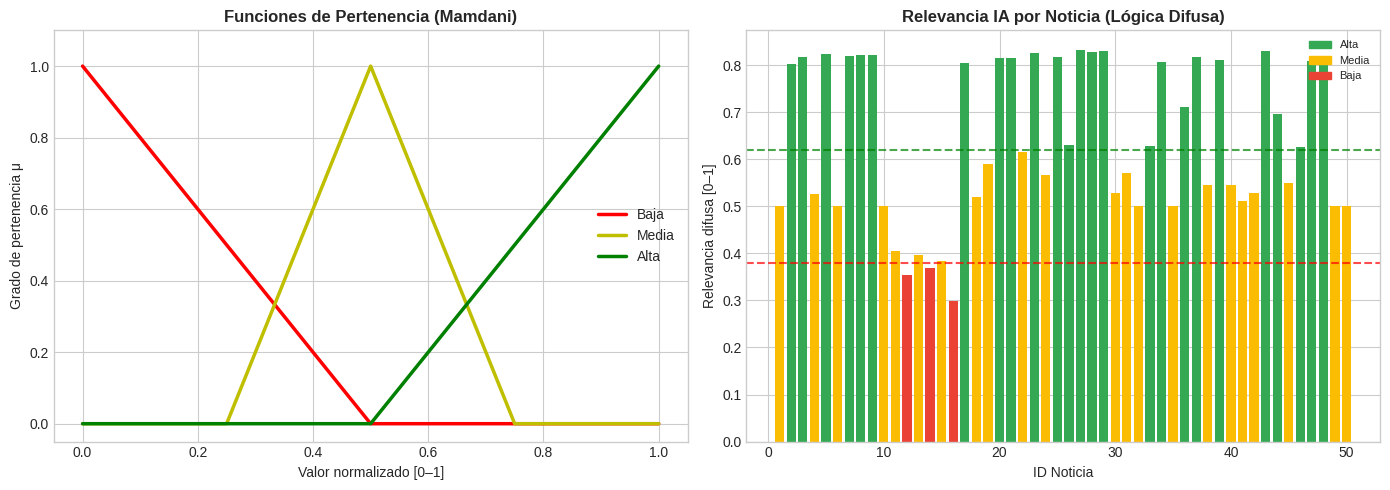

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Funciones de pertenencia
ax1.plot(x_univ, mf_baja,  'r-',  linewidth=2.5, label='Baja')
ax1.plot(x_univ, mf_media, 'y-',  linewidth=2.5, label='Media')
ax1.plot(x_univ, mf_alta,  'g-',  linewidth=2.5, label='Alta')
ax1.set_title('Funciones de Pertenencia (Mamdani)', fontweight='bold')
ax1.set_xlabel('Valor normalizado [0–1]')
ax1.set_ylabel('Grado de pertenencia μ')
ax1.legend()
ax1.set_ylim(-0.05, 1.1)

# Relevancia fuzzy por noticia
color_map = {'Alta': '#34a853', 'Media': '#fbbc04', 'Baja': '#ea4335'}
colores_barra = [color_map[n] for n in df['nivel_relevancia']]
ax2.bar(df['id'], df['fuzzy_relevancia'], color=colores_barra)
ax2.axhline(0.62, color='green',  linestyle='--', alpha=0.7, label='Umbral media/alta (0.62)')
ax2.axhline(0.38, color='red',    linestyle='--', alpha=0.7, label='Umbral baja/media (0.38)')
ax2.set_title('Relevancia IA por Noticia (Lógica Difusa)', fontweight='bold')
ax2.set_xlabel('ID Noticia')
ax2.set_ylabel('Relevancia difusa [0–1]')
ax2.legend(fontsize=8)

from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for l, c in color_map.items()]
ax2.legend(handles=legend_patches, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('fuzzy_relevancia.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Sistema Experto

Se aplica un sistema experto basado en reglas IF-THEN que combina el **nivel de relevancia difusa** con la **categoría del modelo** para asignar una etiqueta interpretable (`categoria_experta`).

| Relevancia | Categoría modelo | → Categoría experta |
|---|---|---|
| Alta | regulación | IA Regulatoria |
| Alta | empleo | IA y Trabajo |
| Alta | sanidad | IA Sanitaria |
| Alta | ciberseguridad | IA y Ciberseguridad |
| Alta | educación | IA Educativa |
| Alta | administración pública | IA en Administración |
| Alta | economía digital | IA Económica |
| Media | regulación / ciberseguridad | Tecnología Regulada |
| Media | empleo / educación | Impacto Social Moderado |
| Media | otros | Digitalización General |
| Baja | cualquiera | Impacto IA Reducido |

In [19]:
def sistema_experto(row):
    relevancia = row['nivel_relevancia']
    cat = row['categoria_modelo']

    if relevancia == 'Alta':
        if cat == 'regulación':              return 'IA Regulatoria'
        elif cat == 'empleo':               return 'IA y Trabajo'
        elif cat == 'sanidad':              return 'IA Sanitaria'
        elif cat == 'ciberseguridad':       return 'IA y Ciberseguridad'
        elif cat == 'educación':            return 'IA Educativa'
        elif cat == 'administración pública': return 'IA en Administración'
        elif cat == 'economía digital':     return 'IA Económica'
        else:                               return 'IA General — Alta Relevancia'

    elif relevancia == 'Media':
        if cat in ('regulación', 'ciberseguridad'):   return 'Tecnología Regulada'
        elif cat in ('empleo', 'educación'):          return 'Impacto Social Moderado'
        else:                                         return 'Digitalización General'

    else:  # Baja
        return 'Impacto IA Reducido'

df['categoria_experta'] = df.apply(sistema_experto, axis=1)

print('✓ Sistema experto aplicado')
print(f'\nDistribución de categorías expertas:')
print(df['categoria_experta'].value_counts().to_string())

✓ Sistema experto aplicado

Distribución de categorías expertas:
categoria_experta
Tecnología Regulada             11
IA Regulatoria                   9
Digitalización General           8
IA General — Alta Relevancia     8
Impacto IA Reducido              3
Impacto Social Moderado          3
IA Sanitaria                     3
IA y Ciberseguridad              2
IA Económica                     1
IA en Administración             1
IA Educativa                     1


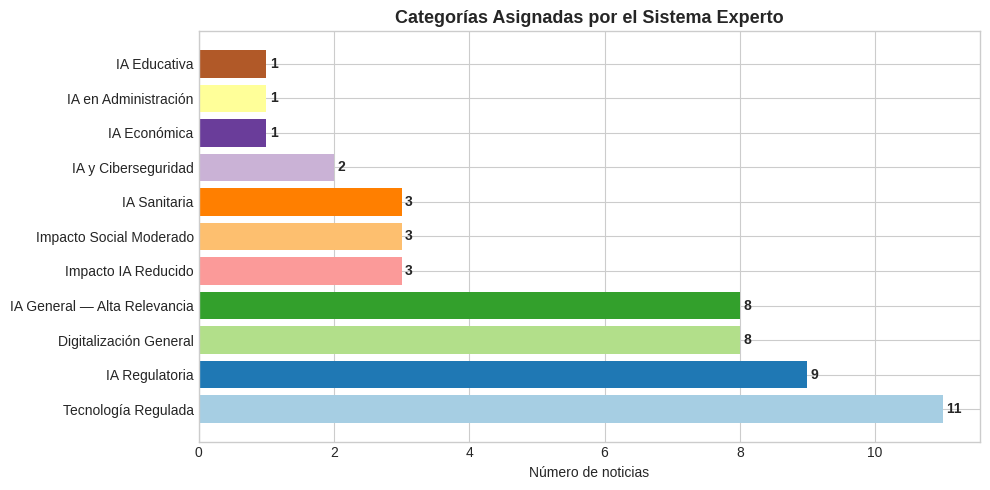

In [20]:
conteo_experto = df['categoria_experta'].value_counts()
colores_exp = plt.cm.Paired(np.linspace(0, 1, len(conteo_experto)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(conteo_experto.index, conteo_experto.values, color=colores_exp)
ax.set_title('Categorías Asignadas por el Sistema Experto', fontweight='bold', fontsize=13)
ax.set_xlabel('Número de noticias')
for bar, val in zip(bars, conteo_experto.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sistema_experto.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Índice IA Compuesto

Se calcula un índice sintético ponderado que combina las cuatro señales del análisis:

$$\text{IA\_INDEX} = 0{,}4 \times \text{score\_modelo} + 0{,}3 \times \text{freq\_ia} + 0{,}2 \times \text{densidad} + 0{,}1 \times \text{fuzzy}$$

| Componente | Peso | Justificación |
|---|---|---|
| `score_modelo` | 0.4 | Mayor peso: semántica profunda del modelo |
| `freq_ia` | 0.3 | Presencia explícita del término IA |
| `densidad` | 0.2 | Densidad de vocabulario tecnológico |
| `fuzzy_relevancia` | 0.1 | Agregación difusa de señales |

Todos los componentes están normalizados en [0, 1].

In [21]:
df['ia_index'] = (
    0.4 * df['score_modelo'] +
    0.3 * df['freq_ia_norm'] +
    0.2 * df['densidad_norm'] +
    0.1 * df['fuzzy_relevancia']
)

top10 = df.nlargest(10, 'ia_index').reset_index(drop=True)

print('═' * 90)
print('  TOP 10 NOTICIAS POR ÍNDICE IA')
print('═' * 90)
for i, row in top10.iterrows():
    print(f"\n  {i+1:>2}. [{row['ia_index']:.3f}] {row['titulo'][:72]}")
    print(f"       Modelo: {row['categoria_modelo']:28s} | Experta: {row['categoria_experta']}")

══════════════════════════════════════════════════════════════════════════════════════════
  TOP 10 NOTICIAS POR ÍNDICE IA
══════════════════════════════════════════════════════════════════════════════════════════

   1. [0.831] La UE impulsa la IA con estrategias y acciones concretas de financiación
       Modelo: inteligencia artificial      | Experta: IA General — Alta Relevancia

   2. [0.825] El Reglamento Europeo de IA exigirá etiquetar el contenido generado por 
       Modelo: regulación                   | Experta: IA Regulatoria

   3. [0.824] La UE prepara para 2026 una profunda reconfiguración de la economía digi
       Modelo: economía digital             | Experta: IA Económica

   4. [0.800] España refuerza la digitalización sanitaria con nuevas convocatorias de 
       Modelo: sanidad                      | Experta: IA Sanitaria

   5. [0.788] Red.es lanza la convocatoria RedIA Salud con 50 millones para proyectos 
       Modelo: sanidad                      | Experta: I

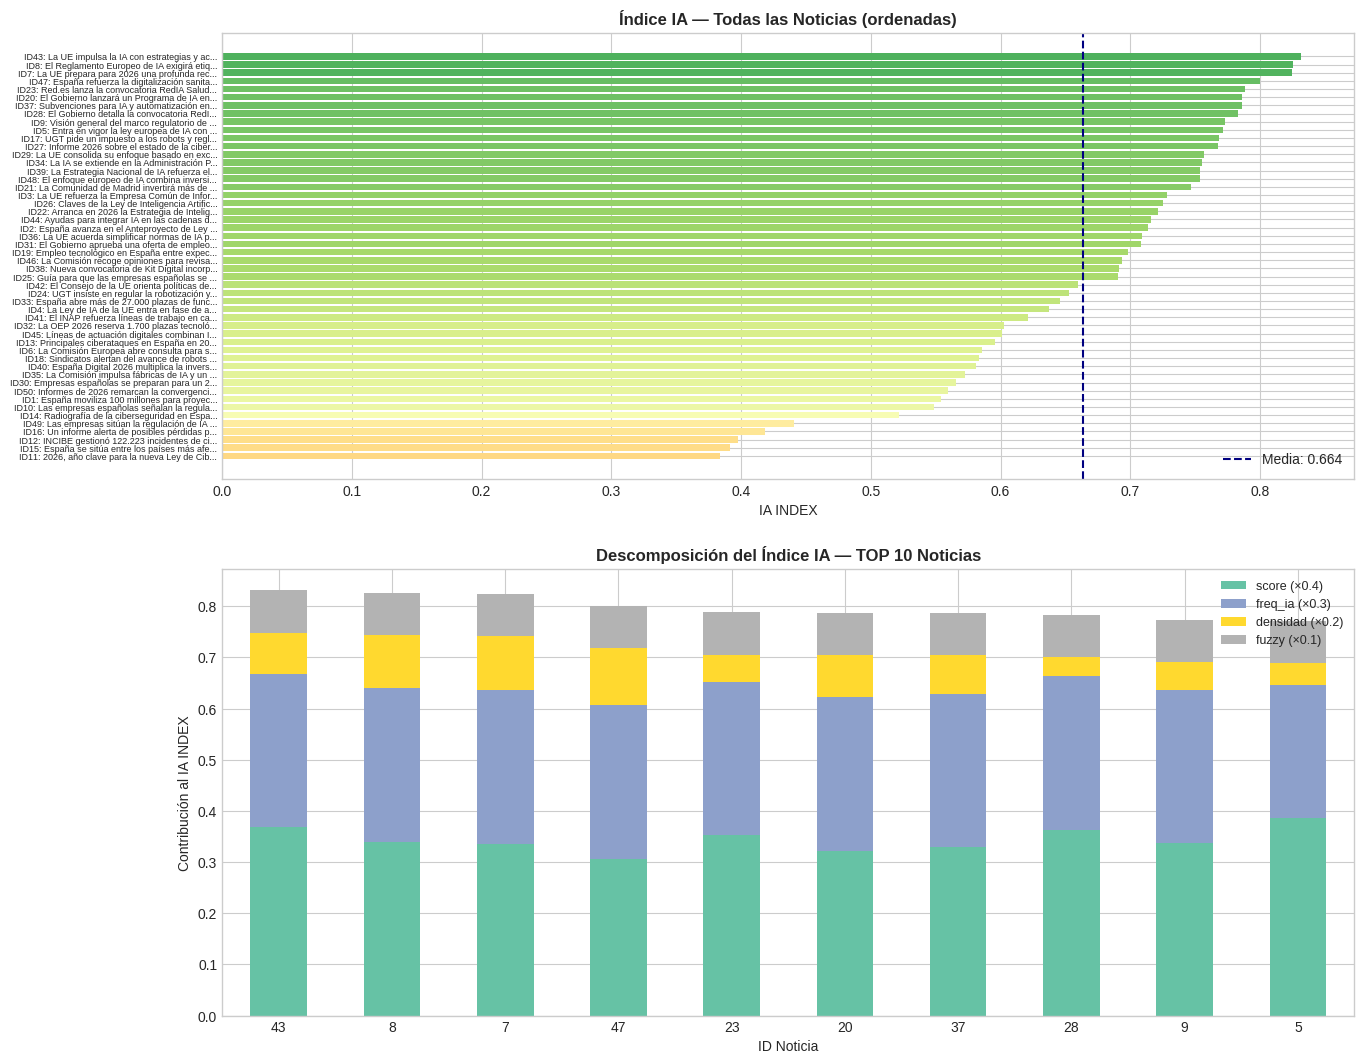

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))

# — Todas las noticias ordenadas por IA INDEX
df_ord = df.sort_values('ia_index', ascending=True).reset_index(drop=True)
cmap_vals = plt.cm.RdYlGn(df_ord['ia_index'].values)
ax1.barh(range(len(df_ord)), df_ord['ia_index'], color=cmap_vals)
labels_y = [
    f"ID{int(row['id'])}: {row['titulo'][:40]}..."
    for _, row in df_ord.iterrows()
]
ax1.set_yticks(range(len(df_ord)))
ax1.set_yticklabels(labels_y, fontsize=6.5)
ax1.axvline(df['ia_index'].mean(), color='navy', linestyle='--',
            label=f'Media: {df["ia_index"].mean():.3f}')
ax1.set_title('Índice IA — Todas las Noticias (ordenadas)', fontweight='bold')
ax1.set_xlabel('IA INDEX')
ax1.legend()

# — Descomposición del índice en TOP 10
comp = pd.DataFrame({
    'ID': top10['id'].astype(str),
    'score (×0.4)':    top10['score_modelo']     * 0.4,
    'freq_ia (×0.3)':  top10['freq_ia_norm']     * 0.3,
    'densidad (×0.2)': top10['densidad_norm']    * 0.2,
    'fuzzy (×0.1)':    top10['fuzzy_relevancia'] * 0.1,
}).set_index('ID')
comp.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2', edgecolor='none')
ax2.set_title('Descomposición del Índice IA — TOP 10 Noticias', fontweight='bold')
ax2.set_xlabel('ID Noticia')
ax2.set_ylabel('Contribución al IA INDEX')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout(pad=2)
plt.savefig('ia_index.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Conclusiones

### Resultados principales

1. **Clasificación zero-shot eficaz sin entrenamiento:** El modelo `joeddav/xlm-roberta-large-xnli` clasifica correctamente el tema principal de la mayoría de las noticias, con una accuracy aproximada variable según el mapeo de categorías manuales. La limitación principal es que las categorías manuales son compuestas y multietiqueta, mientras el modelo asigna una sola etiqueta.

2. **NLP clásico confirma dominancia de IA y regulación:** Los análisis TF-IDF, bigramas y frecuencias muestran que los términos más recurrentes son *inteligencia artificial*, *regulación*, *ciberseguridad* y *economía digital*, coherentes con el contexto de 2025–2026 (entrada en vigor del AI Act).

3. **Lógica difusa gradúa la relevancia sin umbrales rígidos:** El sistema Mamdani permite clasificar noticias en niveles lingüísticos (baja/media/alta) combinando tres señales complementarias, evitando la binarización artificial de la relevancia.

4. **El sistema experto genera etiquetas accionables:** Las reglas IF-THEN producen categorías interpretables como *IA Regulatoria* o *IA Sanitaria*, útiles para priorizar el análisis humano.

5. **El Índice IA ordena de forma robusta:** Al combinar cuatro señales ponderadas, el ranking resultante es más estable que cualquier métrica individual.

### Limitaciones

- **Dataset reducido:** 50 noticias son insuficientes para entrenamiento; solo válido para análisis exploratorio.
- **Categorías manuales compuestas:** Dificultan la evaluación cuantitativa exacta del modelo.
- **Modelo generalista:** XLM-RoBERTa no está ajustado al dominio periodístico español; un fine-tuning mejoraría significativamente los resultados.
- **Umbrales fuzzy subjetivos:** Los valores de corte (0.38 / 0.62) se han fijado manualmente; podrían optimizarse con datos etiquetados.
- **Sesgo temporal:** La concentración de noticias en 2026 refleja la actualidad del AI Act, no necesariamente la importancia histórica.

### Utilidad práctica

Este pipeline podría desplegarse como sistema de **monitorización automatizada de prensa tecnológica** para:
- Identificar noticias de alto impacto sobre IA sin intervención humana
- Alertar sobre nuevas regulaciones o incidentes de ciberseguridad
- Priorizar el análisis editorial sobre el contenido más relevante

### Mejoras futuras

- **Fine-tuning supervisado:** Entrenar el modelo con noticias etiquetadas del dominio para mejorar la precisión de clasificación.
- **Análisis de sentimiento:** Añadir valoración positiva/negativa del impacto percibido de la IA.
- **Extracción de entidades:** Identificar actores clave (empresas, instituciones, reguladores) con NER.
- **Pipeline en tiempo real:** Ingestión automática de noticias desde RSS o APIs de medios.
- **ANFIS (no implementado):** Combinar lógica difusa con redes neuronales para optimizar los parámetros del sistema fuzzy de forma automática.